# NVIDIA Developer Lifecycle Clustering V11: HDBSCAN Main Strata + Lightweight Dormant

This version keeps the completed/valuable clustering path for `active`, `cooling`, and `at_risk`, and disables expensive dormant HDBSCAN.

Final methodology:

- `active`, `cooling`, `at_risk`: HDBSCAN behavioral clustering
- `dormant`: lightweight rule-based segmentation
- `unactivated` / `unknown`: pseudo-groups
- Per-stratum DuckDB tables are preserved by default
- Existing cluster tables are skipped unless explicitly forced to rerun


In [1]:
# ============================================================
# 0. Imports and setup
# ============================================================

import gc
import warnings
from pathlib import Path

import duckdb
import hdbscan
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)

DB_PATH = globals().get('DB_PATH', 'developer_project.duckdb')
PROFILE_TABLE = globals().get('PROFILE_TABLE', 'dev_profile_final_v4')
ID_COL = globals().get('ID_COL', 'developer_id')

OUTPUT_DIR = Path('cluster_outputs_v11')
OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_TABLE_PREFIX = 'dev_lifecycle_cluster_membership_v11'
RUN_STATS_TABLE = 'dev_lifecycle_cluster_run_stats_v11'
COMBINED_TABLE = f'{OUTPUT_TABLE_PREFIX}_combined'
FINAL_TABLE = f'{OUTPUT_TABLE_PREFIX}_final'
PROFILE_TABLE_OUT = f'{OUTPUT_TABLE_PREFIX}_profile_summary'

con = duckdb.connect(DB_PATH)
print('Connected to:', DB_PATH)


Connected to: developer_project.duckdb


## 1. Configuration

Full-data settings. The goal is a manageable set of business-interpretable archetypes, not maximum fragmentation.

In [2]:
# ============================================================
# 1. Lifecycle-first clustering configuration
# ============================================================

# HDBSCAN is used only where it provides business value and is computationally feasible:
# active, cooling, and at_risk.
# Dormant is handled later with lightweight rules because 5M+ mostly inactive rows
# make full HDBSCAN slow and low-value.

FEATURES_BY_STRATUM = {
    'active': [
        'log_activity_count_0_30d',
        'log_activity_count_30_90d',
        'unique_activity_types_0_30d',
        'unique_modalities_0_30d',
        'developer_effort_score',
        'weighted_recent_confidence_effort',
        'recent_build_flag',
        'log_build_count_0_30d',
        'build_share_lifetime',
        'activity_velocity_0_30_vs_30_90',
        'log_clipped_lifetime_activity_count_p99',
        'persona_entropy',
    ],
    'cooling': [
        'log_activity_count_30_90d',
        'log_activity_count_90_180d',
        'developer_effort_score',
        'weighted_recent_confidence_effort',
        'build_share_lifetime',
        'high_effort_share_lifetime',
        'log_clipped_lifetime_activity_count_p99',
        'persona_entropy',
    ],
    'at_risk': [
        'log_activity_count_30_90d',
        'log_activity_count_90_180d',
        'developer_effort_score',
        'build_share_lifetime',
        'high_effort_share_lifetime',
        'log_clipped_lifetime_activity_count_p99',
        'persona_entropy',
    ],
    # Used for lightweight dormant segmentation only, not HDBSCAN.
    'dormant': [
        'developer_effort_score',
        'build_share_lifetime',
        'high_effort_share_lifetime',
        'log_clipped_lifetime_activity_count_p99',
        'persona_entropy',
    ],
}

INTERPRETATION_FEATURES = [
    'avg_effort_rank_0_30d',
    'avg_effort_rank_30_90d',
    'avg_effort_rank_90_180d',
    'has_high_effort_0_30d',
    'active_non_builder_0_30d',
    'low_volume_builder_0_30d',
    'has_activity_0_30d',
    'has_activity_30_90d',
    'has_activity_90_180d',
    'log_build_count_30_90d',
    'log_build_count_90_180d',
]

STRATUM_CONFIG = {
    "active": {
    "min_cluster_size": 15000,
    "min_samples": 300,
    "cluster_selection_epsilon": 0.08,
    },
    'cooling': {
        'min_cluster_size': 18000,
        'min_samples': 350,
        'cluster_selection_epsilon': 0.10,
    },
    'at_risk': {
        'min_cluster_size': 90000,
        'min_samples': 1200,
        'cluster_selection_epsilon': 0.18,
    },
}

VALID_STRATA = ['active', 'cooling', 'at_risk', 'dormant', 'unactivated']
MODEL_STRATA = ['active', 'cooling', 'at_risk']
LIGHTWEIGHT_STRATA = ['dormant']
PSEUDO_STRATA = ['unactivated', 'unknown']

# Existing tables are skipped by default. Put a stratum here only if you want to overwrite it.
SKIP_EXISTING_STRATA = True
FORCE_RERUN_STRATA = []  # examples: ['active'], ['dormant'], ['active', 'at_risk']

ALL_MODEL_FEATURES = sorted({f for s in MODEL_STRATA for f in FEATURES_BY_STRATUM[s]})
ALL_LIGHTWEIGHT_FEATURES = sorted({f for s in LIGHTWEIGHT_STRATA for f in FEATURES_BY_STRATUM[s]})
ALL_FEATURES = sorted(set(ALL_MODEL_FEATURES) | set(ALL_LIGHTWEIGHT_FEATURES) | set(INTERPRETATION_FEATURES))

print('Valid strata:', VALID_STRATA)
print('HDBSCAN model strata:', MODEL_STRATA)
print('Lightweight strata:', LIGHTWEIGHT_STRATA)
print('Pseudo strata:', PSEUDO_STRATA)
print('Skip existing strata:', SKIP_EXISTING_STRATA)
print('Force rerun strata:', FORCE_RERUN_STRATA)
print('Total unique features loaded:', len(ALL_FEATURES))

for stratum in MODEL_STRATA:
    features = FEATURES_BY_STRATUM[stratum]
    cfg = STRATUM_CONFIG[stratum]
    print(f"{stratum}: {len(features)} HDBSCAN features | min_cluster_size={cfg['min_cluster_size']} | min_samples={cfg['min_samples']} | epsilon={cfg['cluster_selection_epsilon']}")

for stratum in LIGHTWEIGHT_STRATA:
    features = FEATURES_BY_STRATUM[stratum]
    print(f"{stratum}: {len(features)} lightweight segmentation features | no HDBSCAN")


Valid strata: ['active', 'cooling', 'at_risk', 'dormant', 'unactivated']
HDBSCAN model strata: ['active', 'cooling', 'at_risk']
Lightweight strata: ['dormant']
Pseudo strata: ['unactivated', 'unknown']
Skip existing strata: True
Force rerun strata: []
Total unique features loaded: 25
active: 12 HDBSCAN features | min_cluster_size=15000 | min_samples=300 | epsilon=0.08
cooling: 8 HDBSCAN features | min_cluster_size=18000 | min_samples=350 | epsilon=0.1
at_risk: 7 HDBSCAN features | min_cluster_size=90000 | min_samples=1200 | epsilon=0.18
dormant: 5 lightweight segmentation features | no HDBSCAN


In [3]:
# ============================================================
# 2. Helpers
# ============================================================

def duckdb_table_exists(con, table_name):
    return con.execute(f"""
        SELECT COUNT(*)
        FROM information_schema.tables
        WHERE table_name = '{table_name}'
    """).fetchone()[0] > 0


def safe_existing_columns(con, table_name, columns):
    existing = con.execute(f"DESCRIBE {table_name}").df()['column_name'].tolist()
    return [c for c in columns if c in existing], [c for c in columns if c not in existing]


def make_cluster_key(stratum, labels):
    labels = pd.Series(labels).astype(int)
    return np.where(labels.eq(-1), f'{stratum}_noise', stratum + '_' + labels.astype(str))


def save_df_to_table(con, df, table_name):
    con.register('tmp_save_df', df)
    con.execute(f"""
        CREATE OR REPLACE TABLE {table_name} AS
        SELECT * FROM tmp_save_df
    """)
    con.unregister('tmp_save_df')


def append_df_to_table(con, df, table_name):
    con.register('tmp_append_df', df)
    con.execute(f"""
        CREATE TABLE IF NOT EXISTS {table_name} AS
        SELECT * FROM tmp_append_df
        WHERE 1 = 0
    """)
    con.execute(f"INSERT INTO {table_name} SELECT * FROM tmp_append_df")
    con.unregister('tmp_append_df')


def cluster_one_stratum(stratum, cfg, features, df, save=True):
    print('\n' + '=' * 80)
    print(f'Clustering full stratum: {stratum}')
    print('=' * 80)
    print('Config:', cfg)
    print('Features:', features)

    sdf = df.loc[df[STRATUM_COL] == stratum, [ID_COL] + features].copy()
    n_rows = len(sdf)
    print('Rows:', n_rows)

    if n_rows == 0:
        print('No rows for this stratum. Skipping.')
        return None, None

    if n_rows < cfg['min_cluster_size'] * 2:
        print('Too few rows for stable clustering. Assigning all rows to cluster 0.')
        out = pd.DataFrame({
            ID_COL: sdf[ID_COL].values,
            'stratum': stratum,
            'hdbscan_cluster': 0,
            'cluster_probability': np.float32(1.0),
            'outlier_score': np.float32(0.0),
        })
        out['cluster_key'] = f'{stratum}_0'
        n_clusters = 1
        noise_count = 0
        noise_pct = 0.0
    else:
        X_raw = sdf[features].replace([np.inf, -np.inf], np.nan)
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler()),
        ])
        X = pipe.fit_transform(X_raw).astype('float32')

        model = hdbscan.HDBSCAN(
            min_cluster_size=cfg['min_cluster_size'],
            min_samples=cfg['min_samples'],
            cluster_selection_epsilon=cfg['cluster_selection_epsilon'],
            metric='euclidean',
            cluster_selection_method='eom',
            prediction_data=True,
            approx_min_span_tree=True,
            core_dist_n_jobs=-1,
        )
        labels = model.fit_predict(X)

        out = pd.DataFrame({
            ID_COL: sdf[ID_COL].values,
            'stratum': stratum,
            'hdbscan_cluster': labels.astype(int),
            'cluster_probability': model.probabilities_.astype('float32'),
            'outlier_score': model.outlier_scores_.astype('float32'),
        })
        out['cluster_key'] = make_cluster_key(stratum, out['hdbscan_cluster'])

        n_clusters = out.loc[out['hdbscan_cluster'] != -1, 'hdbscan_cluster'].nunique()
        noise_count = int((out['hdbscan_cluster'] == -1).sum())
        noise_pct = noise_count / len(out)

        joblib.dump(pipe, OUTPUT_DIR / f'{stratum}_preprocess_pipeline.joblib')
        joblib.dump(model, OUTPUT_DIR / f'{stratum}_hdbscan_model.joblib')
        del X_raw, X, labels, model, pipe
        gc.collect()

    stat = {
        'stratum': stratum,
        'method': 'hdbscan',
        'n_rows': n_rows,
        'n_features': len(features),
        'features': ', '.join(features),
        'n_clusters_excluding_noise': int(n_clusters),
        'noise_count': int(noise_count),
        'noise_pct': float(noise_pct),
        **cfg,
    }

    if save:
        stratum_table = f'{OUTPUT_TABLE_PREFIX}_{stratum}'
        save_df_to_table(con, out, stratum_table)
        print(f'Saved stratum table to DuckDB: {stratum_table}')
        append_df_to_table(con, pd.DataFrame([stat]), RUN_STATS_TABLE)
        print(f'Updated run stats table: {RUN_STATS_TABLE}')

    summary = (
        out.groupby('cluster_key')
        .agg(
            n_developers=(ID_COL, 'count'),
            avg_probability=('cluster_probability', 'mean'),
            avg_outlier_score=('outlier_score', 'mean'),
        )
        .reset_index()
        .sort_values('n_developers', ascending=False)
    )
    summary['share_within_stratum'] = summary['n_developers'] / summary['n_developers'].sum()
    display(summary)

    del sdf, summary
    gc.collect()
    return out, stat



def check_existing_cluster_tables(strata=None):
    """Check which per-stratum cluster tables currently exist in DuckDB."""
    strata = strata or (MODEL_STRATA + LIGHTWEIGHT_STRATA + PSEUDO_STRATA)
    rows = []
    for stratum in strata:
        table_name = f'{OUTPUT_TABLE_PREFIX}_{stratum}'
        exists = duckdb_table_exists(con, table_name)
        n_rows = None
        if exists:
            n_rows = con.execute(f'SELECT COUNT(*) FROM {table_name}').fetchone()[0]
        rows.append({'stratum': stratum, 'table_name': table_name, 'exists': exists, 'n_rows': n_rows})
    status_df = pd.DataFrame(rows)
    display(status_df)
    return status_df


def save_dormant_lightweight_segmentation(df, save=True):
    """Fast, interpretable dormant segmentation. This replaces expensive dormant HDBSCAN."""
    stratum = 'dormant'
    features = FEATURES_BY_STRATUM[stratum]

    print('\n' + '=' * 80)
    print('Lightweight dormant segmentation')
    print('=' * 80)
    print('Features:', features)

    needed = [ID_COL] + features
    sdf = df.loc[df[STRATUM_COL] == stratum, needed].copy()
    n_rows = len(sdf)
    print('Rows:', n_rows)

    if n_rows == 0:
        print('No dormant rows found. Skipping.')
        return None, None

    for col in features:
        sdf[col] = pd.to_numeric(sdf[col], errors='coerce').fillna(0)

    conditions = [
        sdf['build_share_lifetime'].ge(0.40),
        sdf['developer_effort_score'].ge(2.5) & sdf['high_effort_share_lifetime'].ge(0.30),
        sdf['log_clipped_lifetime_activity_count_p99'].le(1.0),
    ]
    choices = [
        'Dormant_Former_Builders',
        'Dormant_High_Intent_Churn',
        'Dormant_One_Time_Users',
    ]

    sdf['cluster_key'] = np.select(conditions, choices, default='Dormant_Low_Depth')

    dormant_cluster_map = {
        'Dormant_Former_Builders': 0,
        'Dormant_High_Intent_Churn': 1,
        'Dormant_One_Time_Users': 2,
        'Dormant_Low_Depth': 3,
    }

    out = pd.DataFrame({
        ID_COL: sdf[ID_COL].values,
        'stratum': stratum,
        'hdbscan_cluster': sdf['cluster_key'].map(dormant_cluster_map).astype('int32'),
        'cluster_probability': np.float32(1.0),
        'outlier_score': np.float32(0.0),
        'cluster_key': sdf['cluster_key'].values,
    })

    stat = {
        'stratum': stratum,
        'method': 'rule_based_segmentation',
        'n_rows': n_rows,
        'n_features': len(features),
        'features': ', '.join(features),
        'n_clusters_excluding_noise': int(out['cluster_key'].nunique()),
        'noise_count': 0,
        'noise_pct': 0.0,
        'min_cluster_size': None,
        'min_samples': None,
        'cluster_selection_epsilon': None,
    }

    if save:
        stratum_table = f'{OUTPUT_TABLE_PREFIX}_{stratum}'
        save_df_to_table(con, out, stratum_table)
        print(f'Saved dormant segmentation table to DuckDB: {stratum_table}')
        append_df_to_table(con, pd.DataFrame([stat]), RUN_STATS_TABLE)
        print(f'Updated run stats table: {RUN_STATS_TABLE}')

    summary = (
        out.groupby('cluster_key')
        .agg(n_developers=(ID_COL, 'count'))
        .reset_index()
        .sort_values('n_developers', ascending=False)
    )
    summary['share_within_stratum'] = summary['n_developers'] / summary['n_developers'].sum()
    display(summary)

    del sdf, summary
    gc.collect()
    return out, stat


## 3. Load data and derive lifecycle stratum

Auto-detects `lifecycle_stratum` or derives it from common status columns such as `dormancy_status`.

In [4]:
# ============================================================
# 3. Load data and derive lifecycle stratum if needed
# ============================================================

existing_cols = con.execute(f'DESCRIBE {PROFILE_TABLE}').df()['column_name'].tolist()

candidate_stratum_cols = [
    'lifecycle_stratum',
    'dormancy_status',
    'developer_lifecycle_status',
    'lifecycle_status',
]
source_stratum_col = next((c for c in candidate_stratum_cols if c in existing_cols), None)
print('Detected source lifecycle/status column:', source_stratum_col)

load_cols = [ID_COL]
if source_stratum_col:
    load_cols.append(source_stratum_col)

existing_features, missing_features = safe_existing_columns(con, PROFILE_TABLE, ALL_FEATURES)
load_cols += existing_features
load_cols = list(dict.fromkeys(load_cols))

if missing_features:
    print('Missing requested features. They will be created as NaN:')
    for col in missing_features:
        print('-', col)

print('Loading columns:', len(load_cols))
df = con.execute(f"SELECT {', '.join(load_cols)} FROM {PROFILE_TABLE}").df()
print('Loaded rows:', len(df))

for col in missing_features:
    df[col] = np.nan

STRATUM_COL = 'lifecycle_stratum'
if source_stratum_col == 'lifecycle_stratum':
    df[STRATUM_COL] = df[source_stratum_col].astype(str).str.lower().str.strip()
elif source_stratum_col:
    raw_status = df[source_stratum_col].astype(str).str.lower().str.strip()
    raw_status = raw_status.str.replace(' ', '_').str.replace('-', '_')
    df[STRATUM_COL] = raw_status
else:
    raise ValueError('Could not find lifecycle_stratum or dormancy_status in the profile table.')

status_map = {
    'at risk': 'at_risk',
    'atrisk': 'at_risk',
    'at_risk': 'at_risk',
    'active': 'active',
    'cooling': 'cooling',
    'dormant': 'dormant',
    'unactivated': 'unactivated',
    'active_none': 'unactivated',
    'none': 'unactivated',
    'unknown': 'unknown',
    'nan': 'unknown',
    'nat': 'unknown',
}
df[STRATUM_COL] = df[STRATUM_COL].map(lambda x: status_map.get(x, x))
df.loc[~df[STRATUM_COL].isin(VALID_STRATA), STRATUM_COL] = 'unknown'

print('\nLifecycle distribution:')
display(df[STRATUM_COL].value_counts(dropna=False).rename_axis('stratum').reset_index(name='n_developers'))


Detected source lifecycle/status column: dormancy_status
Loading columns: 27
Loaded rows: 9379190

Lifecycle distribution:


,stratum,n_developers
0,dormant,5304852
1,unactivated,1718912
2,at_risk,1580877
3,active,418049
4,cooling,356500


## 3B. Check whether prior cluster tables already exist

Run this before clustering. If your previous run already saved `active`, `cooling`, and `at_risk`, this will show `exists = True` and row counts for those tables.

In [5]:
# ============================================================
# 3B. Check existing cluster tables in DuckDB
# Safe to run anytime
# ============================================================

existing_cluster_tables = check_existing_cluster_tables(
    MODEL_STRATA + LIGHTWEIGHT_STRATA + PSEUDO_STRATA
)

main_completed = existing_cluster_tables.query("stratum in @MODEL_STRATA and exists == True")['stratum'].tolist()
print('Completed HDBSCAN strata found in DB:', main_completed)

missing_main = [s for s in MODEL_STRATA if s not in main_completed]
print('Missing HDBSCAN strata:', missing_main)


,stratum,table_name,exists,n_rows
0,active,dev_lifecycle_cluster_membership_v11_active,True,418049.0
1,cooling,dev_lifecycle_cluster_membership_v11_cooling,True,356500.0
2,at_risk,dev_lifecycle_cluster_membership_v11_at_risk,False,NaN
3,dormant,dev_lifecycle_cluster_membership_v11_dormant,False,NaN
4,unactivated,dev_lifecycle_cluster_membership_v11_unactivated,False,NaN
5,unknown,dev_lifecycle_cluster_membership_v11_unknown,False,NaN


Completed HDBSCAN strata found in DB: ['active', 'cooling']
Missing HDBSCAN strata: ['at_risk']


## 4. Optional reset

Set `RESET_OUTPUTS = True` only if you want to start over. Leave it `False` to preserve completed strata and resume safely.

In [6]:
# ============================================================
# 4. Optional reset
# ============================================================

# Leave False to preserve active/cooling/at_risk tables already created in previous runs.
# Set True only if you intentionally want to drop all V11 output tables.
RESET_OUTPUTS = False

if RESET_OUTPUTS:
    for stratum in MODEL_STRATA + LIGHTWEIGHT_STRATA + PSEUDO_STRATA:
        table_name = f'{OUTPUT_TABLE_PREFIX}_{stratum}'
        con.execute(f'DROP TABLE IF EXISTS {table_name}')
        print('Dropped:', table_name)

    for table_name in [RUN_STATS_TABLE, COMBINED_TABLE, FINAL_TABLE, PROFILE_TABLE_OUT]:
        con.execute(f'DROP TABLE IF EXISTS {table_name}')
        print('Dropped:', table_name)
else:
    print('RESET_OUTPUTS is False. Existing output tables are preserved.')


RESET_OUTPUTS is False. Existing output tables are preserved.


## 5. Run clustering

Saves each stratum to DuckDB immediately after completion and skips any stratum table that already exists.

In [ ]:
# ============================================================
# 5. Full-data HDBSCAN for active/cooling/at_risk only
# Saves each stratum immediately to DuckDB
# Skips existing tables by default
# ============================================================

cluster_run_stats = []

for stratum in MODEL_STRATA:
    stratum_table = f'{OUTPUT_TABLE_PREFIX}_{stratum}'
    table_exists = duckdb_table_exists(con, stratum_table)

    if SKIP_EXISTING_STRATA and table_exists and stratum not in FORCE_RERUN_STRATA:
        n_existing = con.execute(f'SELECT COUNT(*) FROM {stratum_table}').fetchone()[0]
        print(f'Skipping {stratum}: existing table found ({stratum_table}, rows={n_existing}).')
        continue

    cfg = STRATUM_CONFIG[stratum]
    features = FEATURES_BY_STRATUM[stratum]
    out, stat = cluster_one_stratum(stratum, cfg, features, df, save=True)

    if stat is not None:
        cluster_run_stats.append(stat)

    del out
    gc.collect()

cluster_run_stats_df = pd.DataFrame(cluster_run_stats)
if len(cluster_run_stats_df):
    display(cluster_run_stats_df)
else:
    print('No HDBSCAN strata were rerun in this cell.')


Skipping active: existing table found (dev_lifecycle_cluster_membership_v11_active, rows=418049).
Skipping cooling: existing table found (dev_lifecycle_cluster_membership_v11_cooling, rows=356500).

Clustering full stratum: at_risk
Config: {'min_cluster_size': 90000, 'min_samples': 1200, 'cluster_selection_epsilon': 0.18}
Features: ['log_activity_count_30_90d', 'log_activity_count_90_180d', 'developer_effort_score', 'build_share_lifetime', 'high_effort_share_lifetime', 'log_clipped_lifetime_activity_count_p99', 'persona_entropy']
Rows: 1580877


## 6. Resume leftover strata

Run this after an interruption. It finds missing modeled strata and clusters only those.

In [ ]:
# ============================================================
# 6. Resume missing HDBSCAN strata only
# Safe to run anytime
# ============================================================

completed_strata = []
missing_strata = []

for stratum in MODEL_STRATA:
    table_name = f'{OUTPUT_TABLE_PREFIX}_{stratum}'
    if duckdb_table_exists(con, table_name):
        completed_strata.append(stratum)
    else:
        missing_strata.append(stratum)

print('Completed HDBSCAN strata:', completed_strata)
print('Missing HDBSCAN strata:', missing_strata)

resumed_stats = []
for stratum in missing_strata:
    cfg = STRATUM_CONFIG[stratum]
    features = FEATURES_BY_STRATUM[stratum]
    out, stat = cluster_one_stratum(stratum, cfg, features, df, save=True)
    if stat is not None:
        resumed_stats.append(stat)
    del out
    gc.collect()

resumed_stats_df = pd.DataFrame(resumed_stats)
if len(resumed_stats_df):
    display(resumed_stats_df)
else:
    print('No missing HDBSCAN strata to resume.')


Completed HDBSCAN strata: ['active', 'cooling', 'at_risk']
Missing HDBSCAN strata: []
No missing HDBSCAN strata to resume.


## 7. Lightweight dormant segmentation and pseudo-groups

Dormant is intentionally not clustered with HDBSCAN. It is segmented with fast, interpretable rules because full dormant HDBSCAN is too slow and creates low-value micro-clusters.

In [ ]:
# ============================================================
# 7A. Lightweight dormant segmentation
# Safe to run anytime; skips existing table unless forced
# ============================================================

dormant_table = f'{OUTPUT_TABLE_PREFIX}_dormant'

if SKIP_EXISTING_STRATA and duckdb_table_exists(con, dormant_table) and 'dormant' not in FORCE_RERUN_STRATA:
    n_existing = con.execute(f'SELECT COUNT(*) FROM {dormant_table}').fetchone()[0]
    print(f'Skipping dormant: existing table found ({dormant_table}, rows={n_existing}).')
else:
    out_dormant, dormant_stat = save_dormant_lightweight_segmentation(df, save=True)
    del out_dormant
    gc.collect()



Lightweight dormant segmentation
Features: ['developer_effort_score', 'build_share_lifetime', 'high_effort_share_lifetime', 'log_clipped_lifetime_activity_count_p99', 'persona_entropy']
Rows: 5304852
Saved dormant segmentation table to DuckDB: dev_lifecycle_cluster_membership_v11_dormant
Updated run stats table: dev_lifecycle_cluster_run_stats_v11


,cluster_key,n_developers,share_within_stratum
1,Dormant_Low_Depth,2466341,0.464922
0,Dormant_Former_Builders,1662813,0.313451
2,Dormant_One_Time_Users,1175698,0.221627


## 7B. Unactivated and unknown pseudo-groups

In [ ]:
# ============================================================
# 7B. Save pseudo-groups for unactivated and unknown
# Safe to run anytime; skips existing tables unless forced
# ============================================================

for pseudo_stratum in PSEUDO_STRATA:
    table_name = f'{OUTPUT_TABLE_PREFIX}_{pseudo_stratum}'
    table_exists = duckdb_table_exists(con, table_name)

    if SKIP_EXISTING_STRATA and table_exists and pseudo_stratum not in FORCE_RERUN_STRATA:
        n_existing = con.execute(f'SELECT COUNT(*) FROM {table_name}').fetchone()[0]
        print(f'Skipping {pseudo_stratum}: existing table found ({table_name}, rows={n_existing}).')
        continue

    pseudo_df = df.loc[df[STRATUM_COL] == pseudo_stratum, [ID_COL]].copy()
    print(pseudo_stratum, 'rows:', len(pseudo_df))

    if len(pseudo_df) == 0:
        continue

    out = pd.DataFrame({
        ID_COL: pseudo_df[ID_COL].values,
        'stratum': pseudo_stratum,
        'hdbscan_cluster': -99,
        'cluster_probability': np.float32(1.0),
        'outlier_score': np.float32(0.0),
        'cluster_key': pseudo_stratum,
    })

    save_df_to_table(con, out, table_name)
    print(f'Saved pseudo-group table: {table_name}')

    del pseudo_df, out
    gc.collect()


unactivated rows: 1721230
Saved pseudo-group table: dev_lifecycle_cluster_membership_v11_unactivated
unknown rows: 0


## 8. Rebuild combined/final tables

Safe to run anytime. Uses all completed stratum tables.

In [ ]:
# ============================================================
# 8. Rebuild combined and final membership tables
# Safe to run anytime
# ============================================================

all_possible_strata = MODEL_STRATA + LIGHTWEIGHT_STRATA + PSEUDO_STRATA
completed_tables = []

for stratum in all_possible_strata:
    table_name = f'{OUTPUT_TABLE_PREFIX}_{stratum}'
    if duckdb_table_exists(con, table_name):
        completed_tables.append(table_name)

print('Tables included in final output:')
for table in completed_tables:
    print('-', table)

if not completed_tables:
    raise ValueError('No completed stratum tables found yet.')

union_sql = '\nUNION ALL\n'.join([f'SELECT * FROM {table}' for table in completed_tables])

con.execute(f"""
    CREATE OR REPLACE TABLE {COMBINED_TABLE} AS
    {union_sql}
""")

con.execute(f"""
    CREATE OR REPLACE TABLE {FINAL_TABLE} AS
    SELECT
        *,
        CASE
            WHEN stratum = 'active' THEN 'accelerating_or_active'
            WHEN stratum = 'cooling' THEN 'declining'
            WHEN stratum = 'at_risk' THEN 'at_risk'
            WHEN stratum = 'dormant' THEN 'steady_inactive'
            WHEN stratum = 'unactivated' THEN 'not_activated'
            ELSE 'unknown'
        END AS adoption_direction,
        CAST('' AS VARCHAR) AS proposed_business_label,
        CAST('' AS VARCHAR) AS interpretation_notes,
        CAST('' AS VARCHAR) AS recommended_action
    FROM {COMBINED_TABLE}
""")

summary_df = con.execute(f"""
    SELECT stratum, cluster_key, COUNT(*) AS n_developers
    FROM {FINAL_TABLE}
    GROUP BY stratum, cluster_key
    ORDER BY stratum, n_developers DESC
""").df()

display(summary_df)
print(f'Saved final membership table: {FINAL_TABLE}')


Tables included in final output:
- dev_lifecycle_cluster_membership_v11_active
- dev_lifecycle_cluster_membership_v11_cooling
- dev_lifecycle_cluster_membership_v11_at_risk
- dev_lifecycle_cluster_membership_v11_dormant
- dev_lifecycle_cluster_membership_v11_unactivated


,stratum,cluster_key,n_developers
0,active,active_5,155026
1,active,active_noise,105723
2,active,active_1,66683
3,active,active_3,29395
4,active,active_2,24653
5,active,active_4,18554
6,active,active_0,18015
7,at_risk,at_risk_0,436295
8,at_risk,at_risk_5,365945
9,at_risk,at_risk_2,210377


Saved final membership table: dev_lifecycle_cluster_membership_v11_final


## 9. Cluster profile summary

In [ ]:
# ============================================================
# 9. Build cluster profile summary
# ============================================================

profile_cols = [ID_COL] + ALL_FEATURES
profile_cols_existing = [c for c in profile_cols if c in df.columns]
profile_df = df[profile_cols_existing].copy()

membership_df = con.execute(f'SELECT * FROM {FINAL_TABLE}').df()
joined = membership_df.merge(profile_df, on=ID_COL, how='left')

numeric_profile_features = [c for c in ALL_FEATURES if c in joined.columns]

agg_dict = {
    ID_COL: 'count',
    'cluster_probability': 'mean',
    'outlier_score': 'mean',
}
for col in numeric_profile_features:
    agg_dict[col] = 'mean'

cluster_profile = (
    joined
    .groupby(['stratum', 'cluster_key'], dropna=False)
    .agg(agg_dict)
    .reset_index()
    .rename(columns={ID_COL: 'n_developers', 'cluster_probability': 'avg_probability', 'outlier_score': 'avg_outlier_score'})
)

cluster_profile['share_within_stratum'] = cluster_profile['n_developers'] / cluster_profile.groupby('stratum')['n_developers'].transform('sum')

front_cols = ['stratum', 'cluster_key', 'n_developers', 'share_within_stratum', 'avg_probability', 'avg_outlier_score']
other_cols = [c for c in cluster_profile.columns if c not in front_cols]
cluster_profile = cluster_profile[front_cols + other_cols]

save_df_to_table(con, cluster_profile, PROFILE_TABLE_OUT)
print(f'Saved cluster profile table: {PROFILE_TABLE_OUT}')
display(cluster_profile.sort_values(['stratum', 'n_developers'], ascending=[True, False]).head(50))


Saved cluster profile table: dev_lifecycle_cluster_membership_v11_profile_summary


,stratum,cluster_key,n_developers,share_within_stratum,avg_probability,avg_outlier_score,active_non_builder_0_30d,activity_velocity_0_30_vs_30_90,avg_effort_rank_0_30d,avg_effort_rank_30_90d,...,log_build_count_0_30d,log_build_count_30_90d,log_build_count_90_180d,log_clipped_lifetime_activity_count_p99,low_volume_builder_0_30d,persona_entropy,recent_build_flag,unique_activity_types_0_30d,unique_modalities_0_30d,weighted_recent_confidence_effort
5,active,active_5,155026,0.370832,0.975223,0.000000,1.000000,NaN,2.984919,0.000000,...,0.000000,0.000000,0.000004,0.704789,0.000000,0.003732,0.000000,1.000000,1.000000,1.348372
6,active,active_noise,105723,0.252896,0.000000,0.883671,0.744426,4.399515,1.267534,0.539925,...,0.454185,0.209716,0.204459,2.442445,0.116039,0.330692,0.255574,1.141436,1.103686,15.885613
1,active,active_1,66683,0.159510,0.572340,0.427660,1.000000,NaN,0.758235,0.000000,...,0.000000,0.000000,0.000000,1.995850,0.000000,0.024673,0.000000,2.000000,1.000000,1.375184
3,active,active_3,29395,0.070315,0.898670,0.101330,1.000000,1.042376,0.001157,0.542166,...,0.000000,0.000024,0.000000,3.003363,0.000000,0.000028,0.000000,1.000000,1.000000,0.611400
2,active,active_2,24653,0.058972,0.936332,0.063668,1.000000,NaN,2.546528,0.000000,...,0.000000,0.000000,0.000101,1.152619,0.000000,0.236702,0.000000,2.000000,2.000000,2.844312
4,active,active_4,18554,0.044382,0.956937,0.000000,1.000000,NaN,2.998814,0.000000,...,0.000000,0.000000,0.000000,0.707682,0.000000,0.427386,0.000000,1.000000,1.000000,1.349822
0,active,active_0,18015,0.043093,0.977125,0.022875,0.000000,1.000000,2.419006,0.000000,...,0.747799,0.000000,0.000715,1.183797,0.768915,0.291839,1.000000,2.061005,2.000000,2.802301
7,at_risk,at_risk_0,436295,0.275983,0.849448,0.150552,0.000000,NaN,0.000000,0.000000,...,0.000000,0.000000,0.321987,1.366180,0.000000,0.263630,0.000000,0.000000,0.000000,0.647089
12,at_risk,at_risk_5,365945,0.231482,0.818444,0.181556,0.000000,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,2.003192,0.000000,0.354810,0.000000,0.000000,0.000000,0.000000
9,at_risk,at_risk_2,210377,0.133076,0.825187,0.174813,0.000000,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.098615,0.000000,0.210564,0.000000,0.000000,0.000000,0.000000


## 10. Visual diagnostics

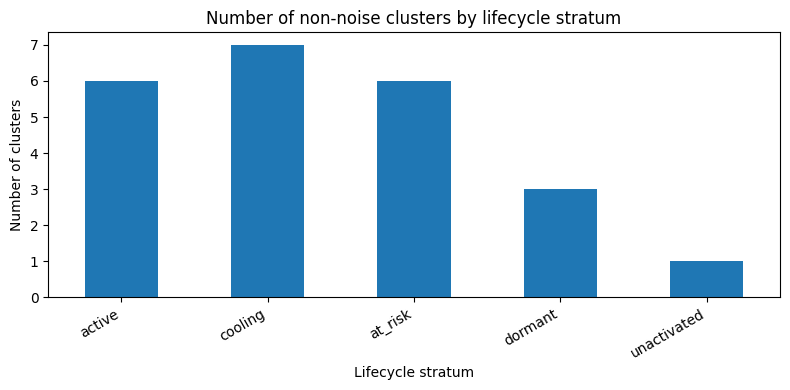

In [ ]:
# ============================================================
# 10A. Cluster counts by stratum
# ============================================================

counts_by_stratum = (
    cluster_profile
    .loc[~cluster_profile['cluster_key'].str.contains('noise', na=False)]
    .groupby('stratum')['cluster_key']
    .nunique()
    .reindex(VALID_STRATA)
    .dropna()
)

plt.figure(figsize=(8, 4))
counts_by_stratum.plot(kind='bar')
plt.title('Number of non-noise clusters by lifecycle stratum')
plt.xlabel('Lifecycle stratum')
plt.ylabel('Number of clusters')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


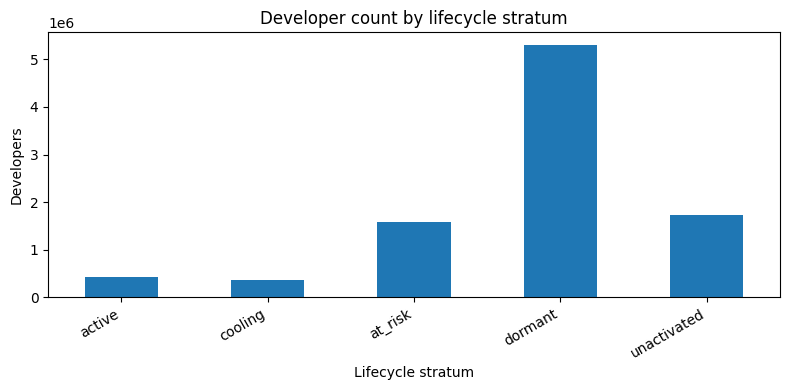

In [ ]:
# ============================================================
# 10B. Developer count by stratum
# ============================================================

stratum_counts = membership_df.groupby('stratum').size().reindex(VALID_STRATA + ['unknown']).dropna()

plt.figure(figsize=(8, 4))
stratum_counts.plot(kind='bar')
plt.title('Developer count by lifecycle stratum')
plt.xlabel('Lifecycle stratum')
plt.ylabel('Developers')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


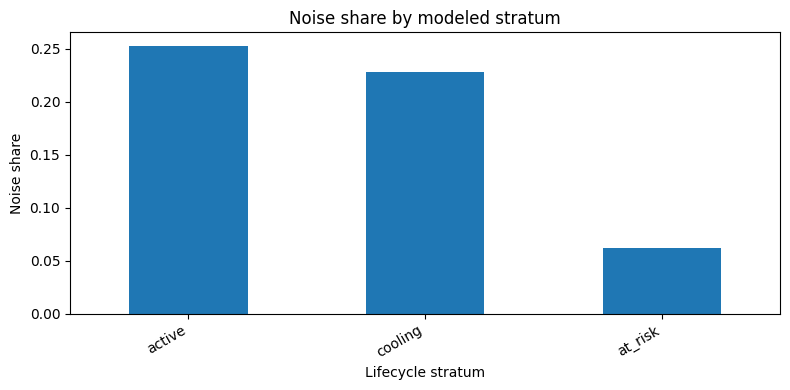

In [ ]:
# ============================================================
# 10C. Noise share by modeled stratum
# ============================================================

noise_df = (
    membership_df
    .assign(is_noise=lambda x: x['hdbscan_cluster'].eq(-1))
    .query('stratum in @MODEL_STRATA')
    .groupby('stratum')['is_noise']
    .mean()
    .reindex(MODEL_STRATA)
)

plt.figure(figsize=(8, 4))
noise_df.plot(kind='bar')
plt.title('Noise share by modeled stratum')
plt.xlabel('Lifecycle stratum')
plt.ylabel('Noise share')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


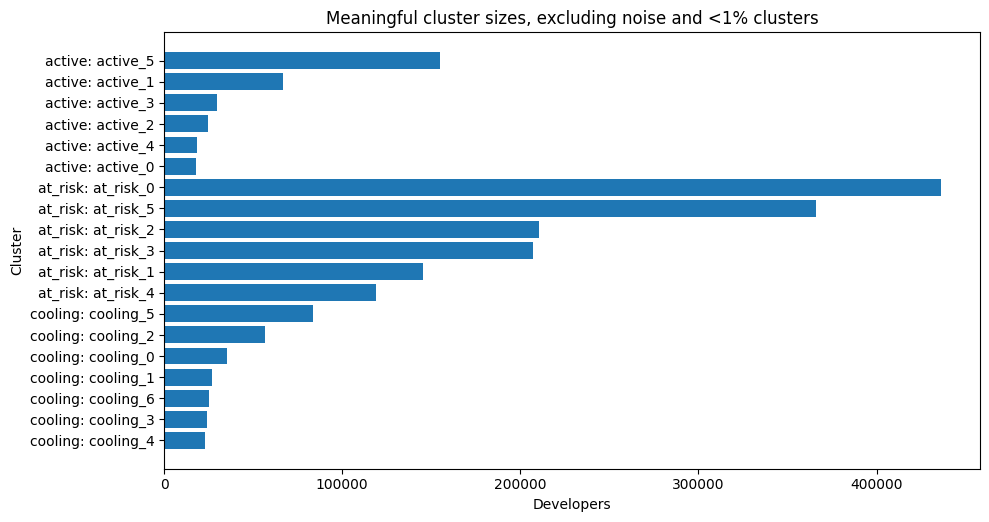

In [ ]:
# ============================================================
# 10D. Meaningful cluster sizes
# ============================================================

plot_sizes = cluster_profile.copy()
plot_sizes = plot_sizes[~plot_sizes['cluster_key'].str.contains('noise', na=False)]
plot_sizes = plot_sizes[plot_sizes['stratum'].isin(MODEL_STRATA)]
plot_sizes = plot_sizes[plot_sizes['share_within_stratum'] >= 0.01]
plot_sizes = plot_sizes.sort_values(['stratum', 'n_developers'], ascending=[True, False])
plot_sizes['plot_label'] = plot_sizes['stratum'] + ': ' + plot_sizes['cluster_key']

plt.figure(figsize=(10, max(4, 0.28 * len(plot_sizes))))
plt.barh(plot_sizes['plot_label'], plot_sizes['n_developers'])
plt.title('Meaningful cluster sizes, excluding noise and <1% clusters')
plt.xlabel('Developers')
plt.ylabel('Cluster')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


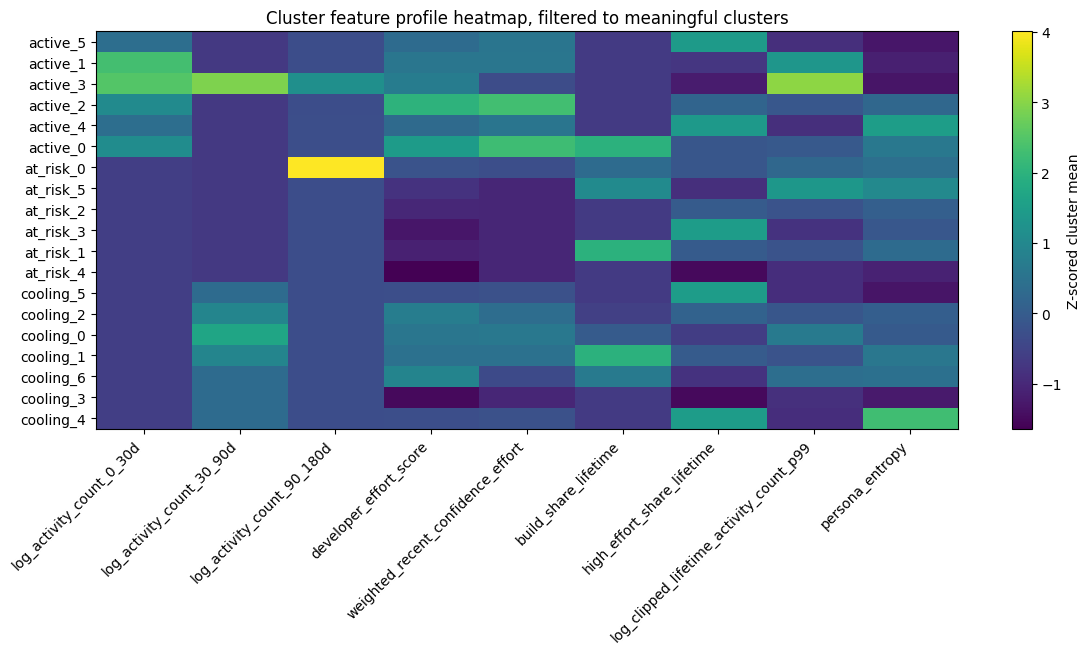

In [ ]:
# ============================================================
# 10E. Filtered cluster feature heatmap
# ============================================================

heatmap_features = [
    'log_activity_count_0_30d',
    'log_activity_count_30_90d',
    'log_activity_count_90_180d',
    'developer_effort_score',
    'weighted_recent_confidence_effort',
    'build_share_lifetime',
    'high_effort_share_lifetime',
    'log_clipped_lifetime_activity_count_p99',
    'persona_entropy',
]
heatmap_features = [c for c in heatmap_features if c in cluster_profile.columns]

plot_df = cluster_profile.copy()
plot_df = plot_df[plot_df['stratum'].isin(MODEL_STRATA)]
plot_df = plot_df[~plot_df['cluster_key'].str.contains('noise', na=False)]
plot_df = plot_df[plot_df['share_within_stratum'] >= 0.01]
plot_df = plot_df.sort_values(['stratum', 'n_developers'], ascending=[True, False])

if len(plot_df) == 0 or len(heatmap_features) == 0:
    print('No clusters/features available for heatmap after filtering.')
else:
    matrix = plot_df[heatmap_features].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    Z = StandardScaler().fit_transform(matrix).astype(float)
    fig_h = max(5, 0.35 * len(plot_df))
    plt.figure(figsize=(12, fig_h))
    plt.imshow(Z, aspect='auto')
    plt.colorbar(label='Z-scored cluster mean')
    plt.yticks(range(len(plot_df)), plot_df['cluster_key'].tolist())
    plt.xticks(range(len(heatmap_features)), heatmap_features, rotation=45, ha='right')
    plt.title('Cluster feature profile heatmap, filtered to meaningful clusters')
    plt.tight_layout()
    plt.show()


## 11. Export outputs

In [ ]:
# ============================================================
# 11. Export outputs
# ============================================================

final_membership = con.execute(f'SELECT * FROM {FINAL_TABLE}').df()
profile_summary = con.execute(f'SELECT * FROM {PROFILE_TABLE_OUT}').df()

final_path = OUTPUT_DIR / f'{FINAL_TABLE}.csv'
profile_path = OUTPUT_DIR / f'{PROFILE_TABLE_OUT}.csv'
run_stats_path = OUTPUT_DIR / f'{RUN_STATS_TABLE}.csv'

final_membership.to_csv(final_path, index=False)
profile_summary.to_csv(profile_path, index=False)

if duckdb_table_exists(con, RUN_STATS_TABLE):
    run_stats = con.execute(f'SELECT * FROM {RUN_STATS_TABLE}').df()
    run_stats.to_csv(run_stats_path, index=False)
    print('Run stats:', run_stats_path)

print('Final membership:', final_path)
print('Profile summary:', profile_path)
print('Rows in final membership:', len(final_membership))


Run stats: cluster_outputs_v11/dev_lifecycle_cluster_run_stats_v11.csv
Final membership: cluster_outputs_v11/dev_lifecycle_cluster_membership_v11_final.csv
Profile summary: cluster_outputs_v11/dev_lifecycle_cluster_membership_v11_profile_summary.csv
Rows in final membership: 9381508


## 12. Suggested interpretation workflow

1. Inspect `dev_lifecycle_cluster_membership_v11_profile_summary`.
2. Confirm the existing-table check shows saved `active`, `cooling`, and `at_risk` tables.
3. Use rule-based dormant segments for high-level inactive-user context only.
4. Assign business labels to meaningful `active`, `cooling`, and `at_risk` clusters.
5. Merge tiny or near-duplicate clusters at the business-label layer if needed.
6. Use `dev_lifecycle_cluster_membership_v11_final` as input to the cluster asset impact notebook.


In [ ]:
# Optional close connection when finished.
con.close()
